# Hotspot-stratified non-hotspot AlphaGenome effects

For each patient–gene pair, this notebook compares the per-variant predicted effects of non-hotspot mutations when the pair also contains a hotspot mutation versus when it does not. Hotspot mutation effects are shown as a third group. Hotspot status follows `hotspot_stratified_hazard_ratios_by_modality.ipynb`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu

def find_project_root():
    for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (path / 'data' / 'TCGA').is_dir():
            return path
    raise FileNotFoundError('Could not find the project root containing data/TCGA.')


PROJECT_ROOT = find_project_root()
RECURRENCE_SCORE_DIR = PROJECT_ROOT / 'data/TCGA/gene_mutation_recurrence'
HOTSPOT_VARIANT_DIR = PROJECT_ROOT / 'data/TCGA/tcga_driver_gene_hotspot_variants_by_cancer'
ALPHAMISSENSE_SCORE_DIR = PROJECT_ROOT / 'data/alphagenome_scores/patient_alphamissense_scores_by_cancer'
OUTPUT_DIR = PROJECT_ROOT / 'results/tcga_hotspot_nonhotspot_predicted_effects'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_GENES = None  # None uses every gene with a per-variant AlphaGenome score file.
# SELECTED_GENES = ["TP53", "KRAS", "PIK3CA", "BRAF", "APC"] # top 5 pancancer
# SELECTED_GENES = ["TP53", "LRP1B", "PIK3CA", "KMT2D", "KMT2C"] # genes acting as top 30 drivers in atleast 50% cancer cohorts
SELECTED_GENES = ["TP53", "LRP1B", "KMT2C", "PIK3CA", "KMT2D", "PTEN", "KRAS", "ARID1A", "NF1", "RB1"] # genes acting as top 100 drivers in atleast 50% cancer cohorts
# SELECTED_GENES = ["TP53", "LRP1B", "KMT2C", "PIK3CA"] # genes acting as top 100 drivers in atleast 2/3 cancer cohorts
SELECTED_MODALITIES = ['ALPHAMISSENSE', 'SPLICE_SITE_USAGE', 'RNA_SEQ', 'ATAC', 'CHIP_TF']
SHOW_HOTSPOT_GROUP = True  # Set False to plot only the first two passenger groups.
PLOT_FONT_SIZE = 13
NORMALIZATION_UPPER_QUANTILE = 0.99
plt.rcParams.update({
    'font.size': PLOT_FONT_SIZE,
    'axes.titlesize': PLOT_FONT_SIZE * 1.15,
    'axes.labelsize': PLOT_FONT_SIZE,
    'xtick.labelsize': PLOT_FONT_SIZE * 0.9,
    'ytick.labelsize': PLOT_FONT_SIZE * 0.9,
})

GROUP_ORDER = [
    'passenger with hotspot',
    'passenger without hotspot',
    'hotspot',
]
GROUP_COLORS = {
    'passenger with hotspot': '#D55E00',
    'passenger without hotspot': '#0072B2',
    'hotspot': '#CC79A7',
}

In [2]:
def score_paths():
    paths = {}
    for path in RECURRENCE_SCORE_DIR.glob('*_alphagenome_scores.tsv'):
        gene = path.name.removesuffix('_alphagenome_scores.tsv')
        if SELECTED_GENES is None or gene in SELECTED_GENES:
            paths[gene] = path
    return paths


def load_variant_scores(paths):
    frames = []
    for gene, path in paths.items():
        columns = pd.read_csv(path, sep='\t', nrows=0).columns
        if 'output_type' not in columns:
            print(f'Skipping {gene}: {path.name} has no output_type column; rerun AlphaGenome scoring to create modality-level scores.')
            continue
        scores = pd.read_csv(path, sep='\t', usecols=['mutation', 'output_type', 'predicted_effect', 'predicted_absolute_effect'])
        scores['gene'] = gene
        frames.append(scores.rename(columns={'output_type': 'modality', 'predicted_effect': 'signed_effect', 'predicted_absolute_effect': 'predicted_effect'}))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def load_hotspot_mutations(genes):
    frames = []
    for path in HOTSPOT_VARIANT_DIR.glob('*_variants.tsv'):
        variants = pd.read_csv(path, sep='\t', dtype=str, usecols=['bcr_patient_barcode', 'mutation', 'gene_name', 'is_hotspot'])
        variants = variants[variants['gene_name'].isin(genes)].copy()
        if variants.empty:
            continue
        variants['cancer'] = path.stem.removesuffix('_variants')
        variants['is_hotspot'] = variants['is_hotspot'].str.lower().eq('true')
        frames.append(variants.rename(columns={'bcr_patient_barcode': 'patient_id', 'gene_name': 'gene'}))
    if not frames:
        return pd.DataFrame()
    variants = pd.concat(frames, ignore_index=True)
    return variants.groupby(['patient_id', 'cancer', 'gene', 'mutation'], as_index=False)['is_hotspot'].any()


def load_alphamissense_scores(genes):
    frames = []
    for path in ALPHAMISSENSE_SCORE_DIR.glob('*.tsv'):
        scores = pd.read_csv(path, sep='\t', usecols=['bcr_patient_barcode', 'cancer_type', 'gene', 'mutation', 'am_pathogenicity'])
        scores = scores[scores['gene'].isin(genes)]
        frames.append(scores.rename(columns={
            'bcr_patient_barcode': 'patient_id',
            'cancer_type': 'cancer',
            'am_pathogenicity': 'predicted_effect',
        }).assign(modality='ALPHAMISSENSE'))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(
        columns=['patient_id', 'cancer', 'gene', 'mutation', 'predicted_effect', 'modality']
    )


paths = score_paths()
variant_scores = load_variant_scores(paths)
patient_variants = load_hotspot_mutations(paths)
alphagenome_effects = patient_variants.merge(variant_scores, on=['gene', 'mutation'], how='inner')
alphamissense_scores = load_alphamissense_scores(paths)
alphamissense_effects = patient_variants.merge(
    alphamissense_scores, on=['patient_id', 'cancer', 'gene', 'mutation'], how='inner'
)
effect_df = pd.concat([alphagenome_effects, alphamissense_effects], ignore_index=True)
variant_directions = (
    alphagenome_effects.assign(absolute_signed_effect=alphagenome_effects['signed_effect'].abs())
    .sort_values('absolute_signed_effect', ascending=False)
    .drop_duplicates(['gene', 'mutation'])
    .assign(effect_direction=lambda scores: np.sign(scores['signed_effect']))
    [['gene', 'mutation', 'effect_direction']]
)
effect_df = effect_df.merge(variant_directions, on=['gene', 'mutation'], how='left')
if SELECTED_MODALITIES is not None:
    effect_df = effect_df[effect_df['modality'].isin(SELECTED_MODALITIES)]
effect_df['predicted_effect'] = pd.to_numeric(effect_df['predicted_effect'], errors='coerce')
effect_df = effect_df.dropna(subset=['predicted_effect'])
alphagenome_genes = sorted(effect_df.loc[effect_df['modality'].ne('ALPHAMISSENSE'), 'gene'].unique())
effect_df = effect_df[effect_df['gene'].isin(alphagenome_genes)].copy()
print('Plotting genes with AlphaGenome variants ({}): {}'.format(len(alphagenome_genes), ', '.join(alphagenome_genes)))

pair_columns = ['patient_id', 'cancer', 'gene']
effect_df['has_hotspot_in_pair'] = effect_df.groupby(pair_columns)['is_hotspot'].transform('any')
effect_df['mutation_group'] = np.select(
    [
        effect_df['is_hotspot'],
        ~effect_df['is_hotspot'] & effect_df['has_hotspot_in_pair'],
    ],
    ['hotspot', 'passenger with hotspot'],
    default='passenger without hotspot',
)
effect_df['mutation_group'] = pd.Categorical(effect_df['mutation_group'], categories=GROUP_ORDER, ordered=True)

selected_gene_effect_df = effect_df.copy()

gene_mutation_groups = effect_df.groupby(['gene', 'is_hotspot'], observed=True).size().unstack(fill_value=0)
eligible_genes = gene_mutation_groups.index[
    gene_mutation_groups.reindex(columns=[False, True], fill_value=0).gt(0).all(axis=1)
]
effect_df = effect_df[effect_df['gene'].isin(eligible_genes)].copy()

print(f'Loaded {len(effect_df):,} scored patient mutations across {effect_df["gene"].nunique():,} genes with both passenger and hotspot mutations.')
effect_df.head()

Plotting genes with AlphaGenome variants (10): ARID1A, KMT2C, KMT2D, KRAS, LRP1B, NF1, PIK3CA, PTEN, RB1, TP53
Loaded 325,212 scored patient mutations across 7 genes with both passenger and hotspot mutations.


,patient_id,cancer,gene,mutation,is_hotspot,modality,signed_effect,predicted_effect,effect_direction,has_hotspot_in_pair,mutation_group
440,TCGA-02-0026,GBM,PTEN,10:87894104-87894109:AGTAAG:A,False,RNA_SEQ,-0.023113,0.029788,1.0,False,passenger without hotspot
443,TCGA-02-0026,GBM,PTEN,10:87894104-87894109:AGTAAG:A,False,ATAC,0.021395,0.051776,1.0,False,passenger without hotspot
446,TCGA-02-0026,GBM,PTEN,10:87894104-87894109:AGTAAG:A,False,CHIP_TF,-0.037188,0.053291,1.0,False,passenger without hotspot
449,TCGA-02-0026,GBM,PTEN,10:87894104-87894109:AGTAAG:A,False,SPLICE_SITE_USAGE,0.902269,0.902269,1.0,False,passenger without hotspot
451,TCGA-02-0026,GBM,PTEN,10:87907839-87907843:CACTA:C,False,RNA_SEQ,0.006913,0.013282,-1.0,False,passenger without hotspot


## All-gene variant effects by hotspot group

Variant scores are z-score normalized within modality, then summed to patient–gene scores and z-score normalized within gene. Set `COMBINED_SCORE_LEVEL` to `patient` to additionally sum gene scores per patient and z-score normalize within cancer type. Overall AG is the maximum normalized score across AlphaGenome modalities before summation.

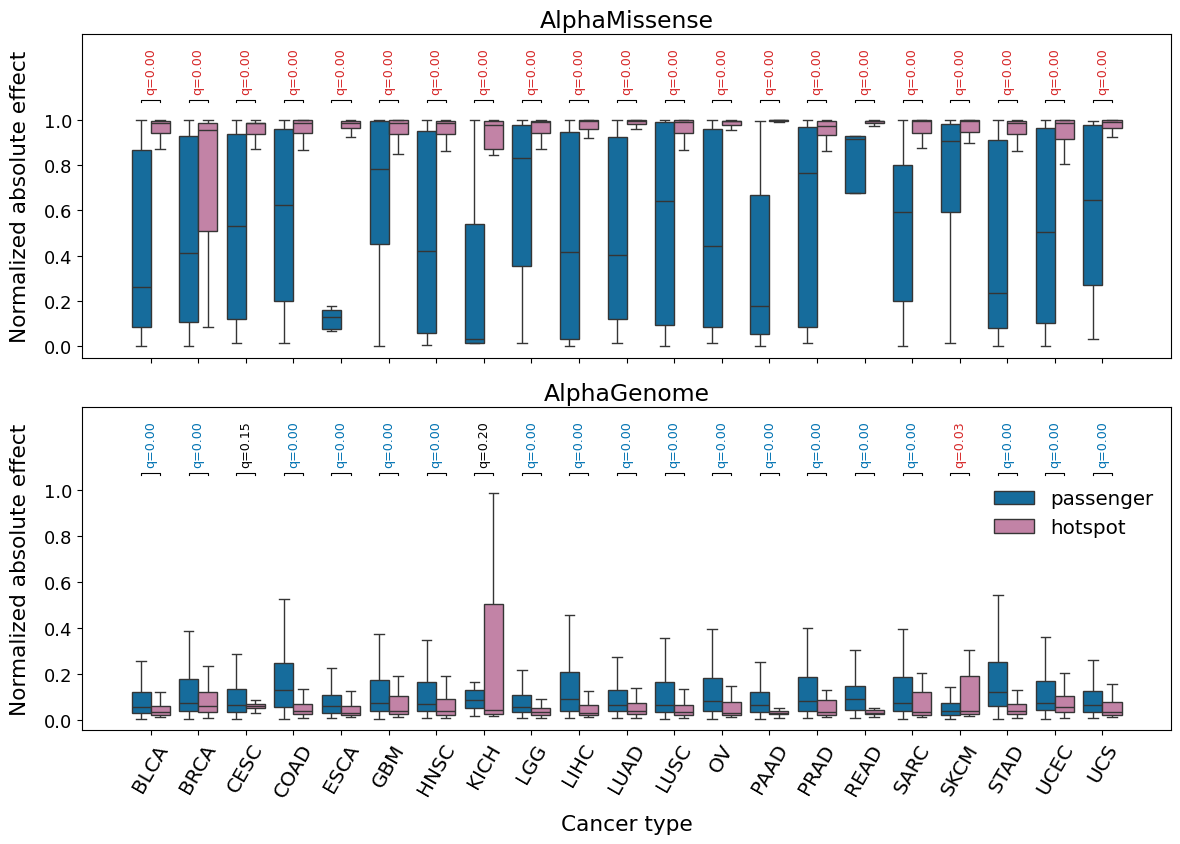

Saved /Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_hotspot_nonhotspot_predicted_effects/by_cancer/all_cancers_passenger_hotspot_comparison.png


In [3]:
CANCER_PLOT_DIR = OUTPUT_DIR / 'by_cancer'
CANCER_PLOT_DIR.mkdir(parents=True, exist_ok=True)

PASSENGER_HOTSPOT_ORDER = ['passenger', 'hotspot']
PASSENGER_HOTSPOT_COLORS = {'passenger': '#0072B2', 'hotspot': '#CC79A7'}

all_gene_normalized_effects = effect_df.copy()
all_gene_normalized_effects['predicted_effect'] = all_gene_normalized_effects['predicted_effect'].abs()
all_gene_normalized_effects['predicted_effect'] = all_gene_normalized_effects.groupby(
    ['gene', 'modality']
)["predicted_effect"].transform(
    lambda scores: 0.0 if scores.max() == scores.min() else (scores - scores.min()) / (scores.max() - scores.min())
)
all_gene_normalized_effects['mutation_group'] = np.where(
    all_gene_normalized_effects['is_hotspot'], 'hotspot', 'passenger'
)
cancer_group_counts = (
    all_gene_normalized_effects[['patient_id', 'cancer', 'gene', 'mutation', 'mutation_group']]
    .drop_duplicates()
    .groupby(['cancer', 'mutation_group']).size()
    .unstack(fill_value=0)
)
eligible_cancers = cancer_group_counts.index[
    cancer_group_counts.reindex(columns=PASSENGER_HOTSPOT_ORDER, fill_value=0).ge(20).all(axis=1)
]
all_gene_normalized_effects = all_gene_normalized_effects[all_gene_normalized_effects['cancer'].isin(eligible_cancers)]

alphamissense_comparison = all_gene_normalized_effects[
    all_gene_normalized_effects['modality'].eq('ALPHAMISSENSE')
].copy()
overall_comparison = all_gene_normalized_effects[
    all_gene_normalized_effects['modality'].ne('ALPHAMISSENSE')
].groupby(
    ['patient_id', 'cancer', 'gene', 'mutation', 'is_hotspot', 'mutation_group'],
    as_index=False,
)["predicted_effect"].max()

cancer_order = sorted(eligible_cancers)
comparison_data = {
    'AlphaMissense': alphamissense_comparison,
    'AlphaGenome': overall_comparison,
}
p_values, directions = {}, {}
for panel, plot_df in comparison_data.items():
    for cancer in cancer_order:
        passenger_scores = plot_df.loc[plot_df['cancer'].eq(cancer) & plot_df['mutation_group'].eq('passenger'), 'predicted_effect'].dropna()
        hotspot_scores = plot_df.loc[plot_df['cancer'].eq(cancer) & plot_df['mutation_group'].eq('hotspot'), 'predicted_effect'].dropna()
        if not passenger_scores.empty and not hotspot_scores.empty:
            key = (panel, cancer)
            p_values[key] = mannwhitneyu(passenger_scores, hotspot_scores, alternative='two-sided').pvalue
            directions[key] = hotspot_scores.median() - passenger_scores.median()

# Benjamini-Hochberg FDR correction across all cancer and panel comparisons in this figure.
ranked_keys = sorted(p_values, key=p_values.get)
q_values, running_minimum = {}, 1.0
for index in range(len(ranked_keys) - 1, -1, -1):
    key = ranked_keys[index]
    running_minimum = min(running_minimum, p_values[key] * len(ranked_keys) / (index + 1))
    q_values[key] = running_minimum

X_TICKLABEL_SIZE = PLOT_FONT_SIZE * 1.1
Y_TICKLABEL_SIZE = PLOT_FONT_SIZE

fig, axes = plt.subplots(2, 1, figsize=(max(12, 0.55 * len(cancer_order)), 9), sharex=True)
for i, (ax, title, plot_df) in enumerate(zip(
    axes,
    ['AlphaMissense', 'AlphaGenome'],
    [alphamissense_comparison, overall_comparison],
)):
    sns.boxplot(
        data=plot_df, x='cancer', y='predicted_effect', hue='mutation_group',
        order=cancer_order, hue_order=PASSENGER_HOTSPOT_ORDER,
        palette=PASSENGER_HOTSPOT_COLORS, showfliers=False, ax=ax,
    )
    ax.set_title(title, fontsize=PLOT_FONT_SIZE * 1.3, pad=5)
    ax.set_xlabel('')
    ax.set_ylabel('Normalized absolute effect', labelpad=10, fontsize=PLOT_FONT_SIZE * 1.2)
    ax.tick_params(axis='y', labelsize=Y_TICKLABEL_SIZE)
    if i == 0 and ax.legend_ is not None:
        ax.legend_.remove()
    else:
        ax.legend(title='', frameon=False, loc='upper right', bbox_to_anchor=(1, 0.8), fontsize=PLOT_FONT_SIZE * 1.1)
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min or 1
    for cancer_index, cancer in enumerate(cancer_order):
        q_value = q_values.get((title, cancer))
        if q_value is None:
            continue
        height = y_max + 0.025 * y_range
        ax.plot([cancer_index - 0.2, cancer_index - 0.2, cancer_index + 0.2, cancer_index + 0.2], [height, height + 0.01 * y_range, height + 0.01 * y_range, height], color='black', linewidth=0.8)
        color = 'black' if q_value >= 0.05 else ('#D62728' if directions[(title, cancer)] > 0 else '#0072B2')
        ax.text(cancer_index, height + 0.035 * y_range, f'q={q_value:.2f}', ha='center', va='bottom', rotation=90, fontsize=PLOT_FONT_SIZE * 0.7, color=color)
    ax.set_ylim(y_min, y_max + 0.3 * y_range)
    ax.set_yticks([tick for tick in ax.get_yticks() if tick >=0 and tick < 1.1])

axes[-1].set_xlabel('Cancer type', labelpad=10, fontsize=PLOT_FONT_SIZE * 1.2)
axes[-1].tick_params(axis='x', rotation=60, labelsize=X_TICKLABEL_SIZE)
# fig.suptitle('Passengers vs hotspots across cancer types', y=0.93, fontsize=PLOT_FONT_SIZE * 1.35)
fig.tight_layout(rect=(0, 0, 1, 0.96))
output = CANCER_PLOT_DIR / 'all_cancers_passenger_hotspot_comparison.png'
fig.savefig(output, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {output}')

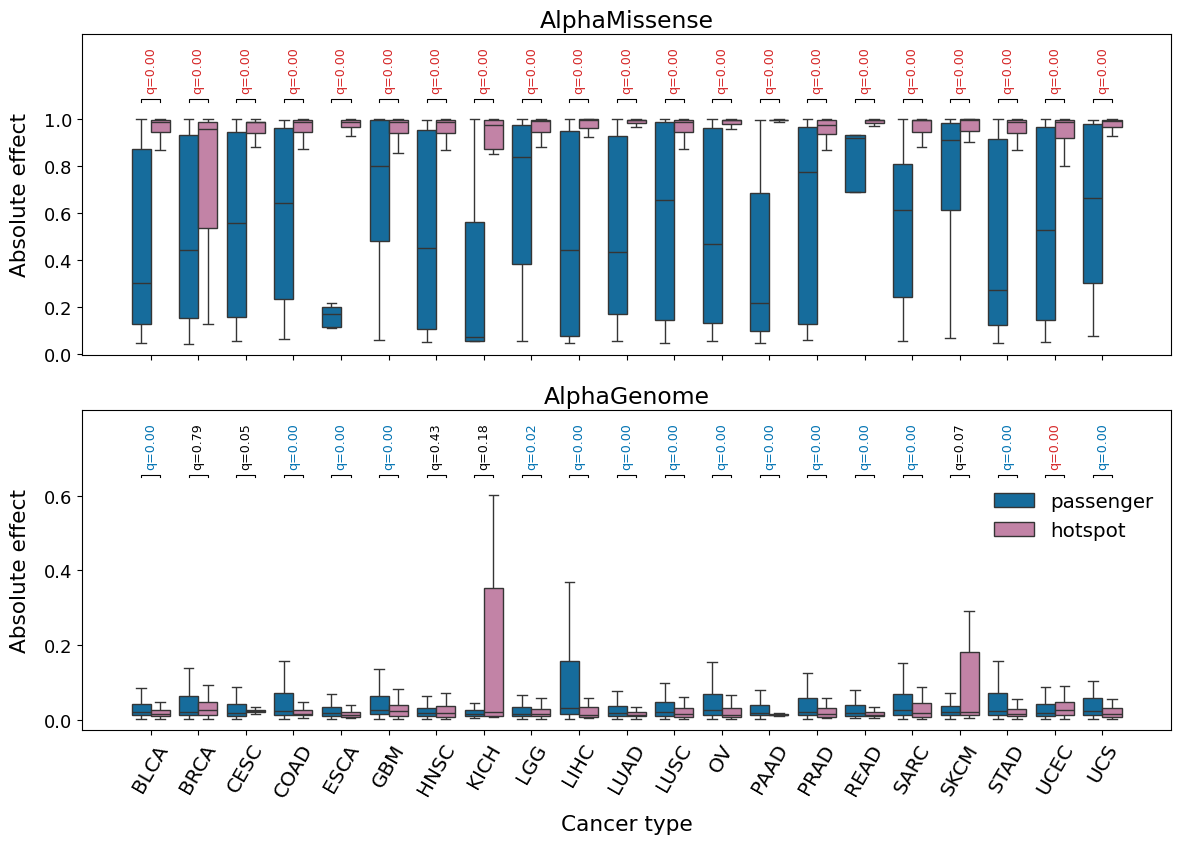

Saved /Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_hotspot_nonhotspot_predicted_effects/by_cancer/all_cancers_passenger_hotspot_unnormalized_comparison.png


In [4]:
all_gene_unnormalized_effects = effect_df.copy()
all_gene_unnormalized_effects['predicted_effect'] = all_gene_unnormalized_effects['predicted_effect'].abs()
all_gene_unnormalized_effects['mutation_group'] = np.where(
    all_gene_unnormalized_effects['is_hotspot'], 'hotspot', 'passenger'
)
cancer_group_counts = (
    all_gene_unnormalized_effects[['patient_id', 'cancer', 'gene', 'mutation', 'mutation_group']]
    .drop_duplicates()
    .groupby(['cancer', 'mutation_group']).size()
    .unstack(fill_value=0)
)
eligible_cancers = cancer_group_counts.index[
    cancer_group_counts.reindex(columns=PASSENGER_HOTSPOT_ORDER, fill_value=0).ge(20).all(axis=1)
]
all_gene_unnormalized_effects = all_gene_unnormalized_effects[
    all_gene_unnormalized_effects['cancer'].isin(eligible_cancers)
]

alphamissense_comparison = all_gene_unnormalized_effects[
    all_gene_unnormalized_effects['modality'].eq('ALPHAMISSENSE')
].copy()
overall_comparison = all_gene_unnormalized_effects[
    all_gene_unnormalized_effects['modality'].ne('ALPHAMISSENSE')
].groupby(
    ['patient_id', 'cancer', 'gene', 'mutation', 'is_hotspot', 'mutation_group'],
    as_index=False,
)["predicted_effect"].max()

cancer_order = sorted(eligible_cancers)
comparison_data = {
    'AlphaMissense': alphamissense_comparison,
    'AlphaGenome': overall_comparison,
}
p_values, directions = {}, {}
for panel, plot_df in comparison_data.items():
    for cancer in cancer_order:
        passenger_scores = plot_df.loc[plot_df['cancer'].eq(cancer) & plot_df['mutation_group'].eq('passenger'), 'predicted_effect'].dropna()
        hotspot_scores = plot_df.loc[plot_df['cancer'].eq(cancer) & plot_df['mutation_group'].eq('hotspot'), 'predicted_effect'].dropna()
        if not passenger_scores.empty and not hotspot_scores.empty:
            key = (panel, cancer)
            p_values[key] = mannwhitneyu(passenger_scores, hotspot_scores, alternative='two-sided').pvalue
            directions[key] = hotspot_scores.median() - passenger_scores.median()

ranked_keys = sorted(p_values, key=p_values.get)
q_values, running_minimum = {}, 1.0
for index in range(len(ranked_keys) - 1, -1, -1):
    key = ranked_keys[index]
    running_minimum = min(running_minimum, p_values[key] * len(ranked_keys) / (index + 1))
    q_values[key] = running_minimum

fig, axes = plt.subplots(2, 1, figsize=(max(12, 0.55 * len(cancer_order)), 9), sharex=True)
for i, (ax, title, plot_df) in enumerate(zip(
    axes,
    ['AlphaMissense', 'AlphaGenome'],
    [alphamissense_comparison, overall_comparison],
)):
    sns.boxplot(
        data=plot_df, x='cancer', y='predicted_effect', hue='mutation_group',
        order=cancer_order, hue_order=PASSENGER_HOTSPOT_ORDER,
        palette=PASSENGER_HOTSPOT_COLORS, showfliers=False, ax=ax,
    )
    ax.set_title(title, fontsize=PLOT_FONT_SIZE * 1.3, pad=5)
    ax.set_xlabel('')
    ax.set_ylabel('Absolute effect', labelpad=10, fontsize=PLOT_FONT_SIZE * 1.2)
    ax.tick_params(axis='y', labelsize=Y_TICKLABEL_SIZE)
    if i == 0 and ax.legend_ is not None:
        ax.legend_.remove()
    else:
        ax.legend(title='', frameon=False, loc='upper right', bbox_to_anchor=(1, 0.8), fontsize=PLOT_FONT_SIZE * 1.1)
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min or 1
    for cancer_index, cancer in enumerate(cancer_order):
        q_value = q_values.get((title, cancer))
        if q_value is None:
            continue
        height = y_max + 0.025 * y_range
        ax.plot([cancer_index - 0.2, cancer_index - 0.2, cancer_index + 0.2, cancer_index + 0.2], [height, height + 0.01 * y_range, height + 0.01 * y_range, height], color='black', linewidth=0.8)
        color = 'black' if q_value >= 0.05 else ('#D62728' if directions[(title, cancer)] > 0 else '#0072B2')
        ax.text(cancer_index, height + 0.035 * y_range, f'q={q_value:.2f}', ha='center', va='bottom', rotation=90, fontsize=PLOT_FONT_SIZE * 0.7, color=color)
    ax.set_ylim(y_min, y_max + 0.3 * y_range)
    ax.set_yticks([tick for tick in ax.get_yticks() if tick >=0 and tick < y_max])

axes[-1].set_xlabel('Cancer type', labelpad=10, fontsize=PLOT_FONT_SIZE * 1.2)
axes[-1].tick_params(axis='x', rotation=60, labelsize=X_TICKLABEL_SIZE)
fig.tight_layout(rect=(0, 0, 1, 0.96))
output = CANCER_PLOT_DIR / 'all_cancers_passenger_hotspot_unnormalized_comparison.png'
fig.savefig(output, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {output}')

## Passenger versus hotspot effects by gene role

Genes are classified using `metadata/cancer_genes.tsv`. Genes annotated as both an oncogene and tumor suppressor gene, or as neither, are excluded.

In [5]:
gene_metadata = pd.read_csv(PROJECT_ROOT / 'metadata/cancer_genes.tsv', sep='\t')
is_oncogene = gene_metadata['Is Oncogene'].eq('Yes')
is_tsg = gene_metadata['Is Tumor Suppressor Gene'].eq('Yes')
gene_roles = gene_metadata.loc[is_oncogene ^ is_tsg, ['Hugo Symbol']].copy()
gene_roles['gene_role'] = np.where(is_oncogene[is_oncogene ^ is_tsg], 'oncogene', 'TSG')
gene_roles = gene_roles.rename(columns={'Hugo Symbol': 'gene'})



## Pan-cancer AlphaMissense and AlphaGenome comparisons

Effects are normalized within gene and modality before pooling across cancer types.

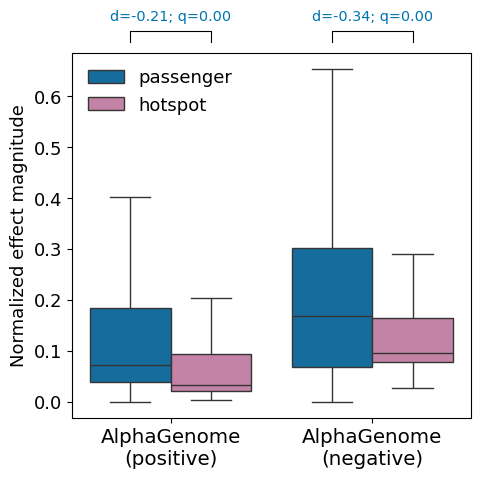

Saved /Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_hotspot_nonhotspot_predicted_effects/by_cancer/pancancer_alphamissense_alphagenome_by_direction.png


In [6]:
def cohens_d(hotspot_scores, passenger_scores):
    n_hotspot, n_passenger = len(hotspot_scores), len(passenger_scores)
    pooled_variance = ((n_hotspot - 1) * hotspot_scores.var(ddof=1) + (n_passenger - 1) * passenger_scores.var(ddof=1)) / (n_hotspot + n_passenger - 2)
    return 0.0 if pooled_variance == 0 else (hotspot_scores.mean() - passenger_scores.mean()) / np.sqrt(pooled_variance)

def prepare_pancancer_effects(panel_effects, aggregate_alphagenome=False):
    panel_effects = panel_effects.copy()
    panel_effects['predicted_effect'] = panel_effects['predicted_effect'].abs()
    panel_effects['predicted_effect'] = panel_effects.groupby(['gene', 'modality'])['predicted_effect'].transform(
        lambda scores: 0.0 if scores.max() == scores.min() else (scores - scores.min()) / (scores.max() - scores.min())
    )
    panel_effects['mutation_group'] = np.where(panel_effects['is_hotspot'], 'hotspot', 'passenger')
    if aggregate_alphagenome:
        panel_effects = panel_effects.groupby(
            ['patient_id', 'cancer', 'gene', 'mutation', 'is_hotspot', 'mutation_group'], as_index=False
        )['predicted_effect'].max()
    panel_effects['gene_adjusted_effect'] = panel_effects.groupby('gene')['predicted_effect'].transform(
        lambda scores: 0.0 if scores.max() == scores.min() else (scores - scores.min()) / (scores.max() - scores.min())
    )
    return panel_effects

alphamissense_pancancer = prepare_pancancer_effects(effect_df[effect_df['modality'].eq('ALPHAMISSENSE')])
positive_alphagenome_pancancer = prepare_pancancer_effects(
    effect_df[effect_df['modality'].ne('ALPHAMISSENSE') & effect_df['effect_direction'].eq(1)], True
)
negative_alphagenome_pancancer = prepare_pancancer_effects(
    effect_df[effect_df['modality'].ne('ALPHAMISSENSE') & effect_df['effect_direction'].eq(-1)], True
)
method_order = ['AlphaGenome\n(positive)', 'AlphaGenome\n(negative)']
pancancer_comparison = pd.concat([
    positive_alphagenome_pancancer.assign(method='AlphaGenome\n(positive)'),
    negative_alphagenome_pancancer.assign(method='AlphaGenome\n(negative)'),
], ignore_index=True)
p_values, effect_sizes = {}, {}
for title in method_order:
    panel_effects = pancancer_comparison[pancancer_comparison['method'].eq(title)]
    passenger = panel_effects.loc[panel_effects['mutation_group'].eq('passenger'), 'gene_adjusted_effect'].dropna()
    hotspot = panel_effects.loc[panel_effects['mutation_group'].eq('hotspot'), 'gene_adjusted_effect'].dropna()
    p_values[title] = mannwhitneyu(passenger, hotspot, alternative='two-sided').pvalue
    effect_sizes[title] = cohens_d(hotspot, passenger)
# Benjamini-Hochberg FDR correction across the three method/direction comparisons.
ranked_titles = sorted(p_values, key=p_values.get)
q_values, running_minimum = {}, 1.0
for index in range(len(ranked_titles) - 1, -1, -1):
    title = ranked_titles[index]
    running_minimum = min(running_minimum, p_values[title] * len(ranked_titles) / (index + 1))
    q_values[title] = running_minimum
PANCANCER_DIRECTION_FIGSIZE = (5, 5)
fig, ax = plt.subplots(figsize=PANCANCER_DIRECTION_FIGSIZE)
sns.boxplot(data=pancancer_comparison, x='method', y='gene_adjusted_effect', hue='mutation_group', order=method_order, hue_order=PASSENGER_HOTSPOT_ORDER, palette=PASSENGER_HOTSPOT_COLORS, showfliers=False, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Normalized effect magnitude')
ax.tick_params(axis='x', labelsize=X_TICKLABEL_SIZE)
ax.tick_params(axis='y', labelsize=Y_TICKLABEL_SIZE)
ax.set_yticks([tick for tick in ax.get_yticks() if tick >=0 and tick < 1.1])
ax.legend(title='', frameon=False, loc='upper left')
for method_index, title in enumerate(method_order):
    color = 'black' if q_values[title] >= 0.05 else ('#D62728' if effect_sizes[title] > 0 else '#0072B2')
    height = 1.03
    ax.plot([method_index - 0.2, method_index - 0.2, method_index + 0.2, method_index + 0.2], [height, height + 0.03, height + 0.03, height], transform=ax.get_xaxis_transform(), clip_on=False, color='black', linewidth=0.8)
    ax.text(method_index, height + 0.05, f'd={effect_sizes[title]:.2f}; q={q_values[title]:.2f}', transform=ax.get_xaxis_transform(), clip_on=False, ha='center', va='bottom', fontsize=PLOT_FONT_SIZE * 0.8, color=color)
fig.tight_layout()
output = CANCER_PLOT_DIR / 'pancancer_alphamissense_alphagenome_by_direction.png'
fig.savefig(output, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {output}')

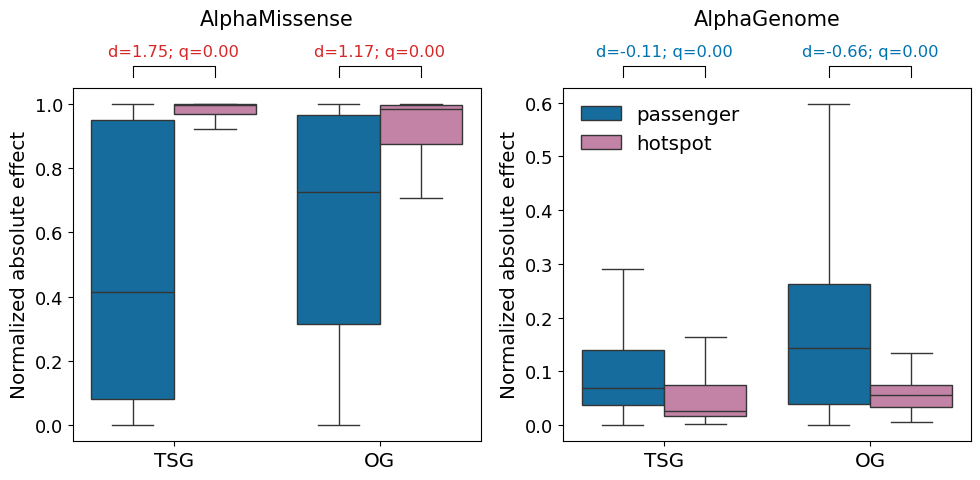

Saved /Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_hotspot_nonhotspot_predicted_effects/by_cancer/pancancer_alphamissense_alphagenome_by_gene_role.png


In [7]:
role_effects = effect_df.merge(gene_roles, on='gene', how='inner').copy()
role_effects['gene_role'] = role_effects['gene_role'].map({'TSG': 'TSG', 'oncogene': 'OG'})
alphamissense_by_role = prepare_pancancer_effects(role_effects[role_effects['modality'].eq('ALPHAMISSENSE')])
alphagenome_by_role = pd.concat([
    prepare_pancancer_effects(role_effects[role_effects['modality'].ne('ALPHAMISSENSE') & role_effects['gene_role'].eq('TSG')], True).assign(gene_role='TSG'),
    prepare_pancancer_effects(role_effects[role_effects['modality'].ne('ALPHAMISSENSE') & role_effects['gene_role'].eq('OG')], True).assign(gene_role='OG'),
], ignore_index=True)
method_by_role = pd.concat([
    alphamissense_by_role.assign(method='AlphaMissense'),
    alphagenome_by_role.assign(method='AlphaGenome'),
], ignore_index=True)
p_values, effect_sizes = {}, {}
for method in ['AlphaMissense', 'AlphaGenome']:
    for gene_role in ['TSG', 'OG']:
        comparison = method_by_role[method_by_role['method'].eq(method) & method_by_role['gene_role'].eq(gene_role)]
        passenger = comparison.loc[comparison['mutation_group'].eq('passenger'), 'gene_adjusted_effect'].dropna()
        hotspot = comparison.loc[comparison['mutation_group'].eq('hotspot'), 'gene_adjusted_effect'].dropna()
        p_values[(method, gene_role)] = mannwhitneyu(passenger, hotspot, alternative='two-sided').pvalue
        effect_sizes[(method, gene_role)] = cohens_d(hotspot, passenger)
# Benjamini-Hochberg FDR correction across the four method-by-role comparisons.
ranked_keys = sorted(p_values, key=p_values.get)
q_values, running_minimum = {}, 1.0
for index in range(len(ranked_keys) - 1, -1, -1):
    key = ranked_keys[index]
    running_minimum = min(running_minimum, p_values[key] * len(ranked_keys) / (index + 1))
    q_values[key] = running_minimum
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for index, (ax, method) in enumerate(zip(axes, ['AlphaMissense', 'AlphaGenome'])):
    panel_effects = method_by_role[method_by_role['method'].eq(method)]
    sns.boxplot(data=panel_effects, x='gene_role', y='gene_adjusted_effect', hue='mutation_group',
        order=['TSG', 'OG'], hue_order=PASSENGER_HOTSPOT_ORDER, palette=PASSENGER_HOTSPOT_COLORS, showfliers=False, ax=ax)
    ax.set_title(method, fontsize=PLOT_FONT_SIZE * 1.15, pad=45)
    ax.set_xlabel('')
    ax.set_ylabel('Normalized absolute effect', fontsize=PLOT_FONT_SIZE * 1.1)
    ax.tick_params(axis='x', labelsize=X_TICKLABEL_SIZE)
    ax.tick_params(axis='y', labelsize=Y_TICKLABEL_SIZE)
    ax.set_yticks([tick for tick in ax.get_yticks() if tick >=0 and tick < 1.1])
    if index == 0:
        ax.legend_.remove()
    else:
        ax.legend(title='', frameon=False, loc='upper left', fontsize=X_TICKLABEL_SIZE)
    for role_index, gene_role in enumerate(['TSG', 'OG']):
        height = 1.03
        ax.plot([role_index - 0.2, role_index - 0.2, role_index + 0.2, role_index + 0.2], [height, height + 0.03, height + 0.03, height], transform=ax.get_xaxis_transform(), clip_on=False, color='black', linewidth=0.8)
        effect_size = effect_sizes[(method, gene_role)]
        color = 'black' if q_values[(method, gene_role)] >= 0.05 else ('#D62728' if effect_size > 0 else '#0072B2')
        ax.text(role_index, height + 0.05, f'd={effect_size:.2f}; q={q_values[(method, gene_role)]:.2f}', transform=ax.get_xaxis_transform(), clip_on=False, ha='center', va='bottom', fontsize=PLOT_FONT_SIZE * 0.9, color=color)
fig.tight_layout()
output = CANCER_PLOT_DIR / 'pancancer_alphamissense_alphagenome_by_gene_role.png'
fig.savefig(output, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {output}')